# Framework

* Use space model to create fans
   * have a grid. Part of the grid is going up (uplift causes erosion). Other part of grid not going up.
   * If you don't let sediment leave from anywhere except bottom left corner, it will force sediment south onto flat plane and fans start building.
   * it will go up and start eroding
   * To change surface roughness and h2O/sed supply
        * chang surface roughness in the surface condition when setting up
        * to change sediment supply: control the uplift rate. this will change the amount of sediment coming off to form fans (more erosion)
        * Changing the amount of water is contained in the k parameter
        * Don't change many things at once, just try one at a time.
        * Component we would need to use is SPACE. Verys traightforward to have half of grid go up and other half go up (ask for help).
        * Challenge will be getting SPACE to run
        * Find tutorial that runs SPACE model, apply it on a grid where half goes up and other half doesnt. Closed on left, right, top, open on bottom for the boundary conditions. It is easy to change the boundary conditions.


## Import necessary packages

In [1]:
import matplotlib.pyplot as plt  # For plotting results; optional
import numpy as np

from landlab import RasterModelGrid, imshow_grid, imshowhs_grid # Grid utility
from landlab import imshow_grid  # For plotting results; optional
from landlab.components import Space  # SPACE model --> main mechanism for routing sediment across the landscape

# Also import useful water and sediment routing components
from landlab.components import DepressionFinderAndRouter, FlowAccumulator, FastscapeEroder, LinearDiffuser, ChannelProfiler


## Set up the grid, with topographic elevation and soil depth fields

In [2]:
num_rows = 50
num_cols = 100
dxy = 50

mg = RasterModelGrid((num_rows, num_cols), xy_spacing=dxy)

# boundary conditons so that only the bottom is open 
mg.set_closed_boundaries_at_grid_edges(bottom_is_closed=False, left_is_closed=True, right_is_closed=True, top_is_closed=True)

# adding fields
z = mg.add_zeros('topographic__elevation', at='node', clobber=True)

soil = mg.add_zeros("soil__depth", at="node", clobber=True)

## Now set a random roughness for the terrain, define the mountain front, slopes, etc.

In [3]:
# set random roughness of terrain 
np.random.seed(42)

#define where the mountain front is 
front_y = 0.5 * mg.y_of_node.max()

#initial slopes 
basin_slope = 0.0005  #can change these
upland_slope = 0.003

#OPTIONAL: add a tilt the landscape -----> need to test this
topo = mg.node_y + mg.node_x / 100000.0

# initiate drainage 
roughness = 0.05 * np.random.rand(mg.number_of_nodes)



# ID upland nodes 
upland = mg.y_of_node >= front_y

#create the distinct highland/lowland 
z[upland] += (50.0 + upland_slope * (mg.y_of_node[upland] - front_y))
z[:] += roughness 

## Set the sediment cover

In [4]:
#initiate with no sediment cover 
soil[:] = 0 

#bedrock here means topography (to begin with) 
bedrock = mg.add_field("bedrock__elevation", z - soil, at="node", clobber=True)

# ~~~~~ or do we want to do it this way:

# Set 2 m of initial soil depth at core nodes
#mg.at_node["soil__depth"][mg.core_nodes] = 2.0  # meters

# Add field 'bedrock__elevation' to the grid
#mg.add_zeros("bedrock__elevation", at="node")

# Sum 'soil__depth' and 'bedrock__elevation'
# to yield 'topographic elevation'
#mg.at_node["bedrock__elevation"][:] = mg.at_node["topographic__elevation"]
#mg.at_node["topographic__elevation"][:] += mg.at_node["soil__depth"]


# Visualize the starting topography

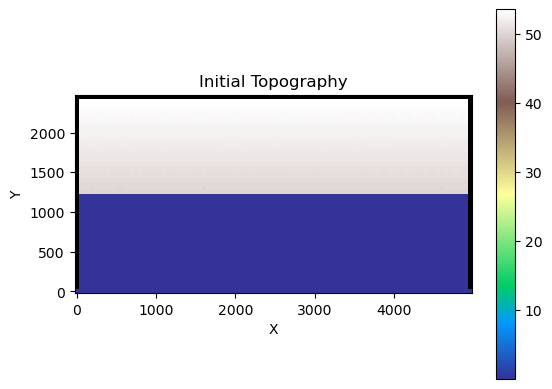

In [5]:
# Let's see our initial topographyyyy 


imshow_grid(mg, "topographic__elevation", cmap="terrain")
plt.title("Initial Topography")
plt.show()

In [6]:
nsteps = 3
uplift_length = 10
for i in range(nsteps):
    mg[0:2, 0:5] += uplift_length # uplift the landscape
plt.imshow(mg)

TypeError: can only concatenate str (not "tuple") to str

In [ ]:

# track sediment flux at the node adjacent to the outlet at lower-left
node_next_to_outlet = num_cols + 1

# Set 2 m of initial soil depth at core nodes
mg.at_node["soil__depth"][mg.core_nodes] = 2.0  # meters

# Set up flow router and SPACE

In [ ]:
# Instantiate flow router
fr = FlowAccumulator(mg, flow_director="FlowDirectorD8")

# Instantiate depression finder and router; optional
df = DepressionFinderAndRouter(mg)

# Instantiate SPACE model with chosen parameters
sp = Space(
    mg,
    K_sed=0.01,
    K_br=0.001,
    F_f=0.0,
    phi=0.0,
    H_star=1.0,
    v_s=5.0,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)

# Run the model

In [ ]:
# Set model timestep
timestep = 1.0  # years

# Set elapsed time to zero
elapsed_time = 0.0  # years

# Set timestep count to zero
count = 0

# Set model run time
run_time = 50.0  # years

# Array to save sediment flux values
sed_flux = np.zeros(int(run_time // timestep))

while elapsed_time < run_time:  # time units of years
    # Run the flow router
    fr.run_one_step()

    # Run the depression finder and router; optional
    df.map_depressions()

    # Run SPACE for one time step
    sp.run_one_step(dt=timestep)

    # Save sediment flux value to array
    sed_flux[count] = mg.at_node["sediment__flux"][node_next_to_outlet]

    # Add to value of elapsed time
    elapsed_time += timestep

    # Increase timestep count
    count += 1

In [ ]:
# Instantiate figure
fig = plt.figure()

# Instantiate subplot
plot = plt.subplot()

# Show sediment flux map
imshow_grid(
    mg,
    "sediment__flux",
    plot_name="Sediment flux",
    var_name="Sediment flux",
    var_units=r"m$^3$/yr",
    grid_units=("m", "m"),
    cmap="terrain",
)

In [ ]:
# Sed flux figure

# Instantiate figure
fig = plt.figure()

# Instantiate subplot
sedfluxplot = plt.subplot()

# Plot data
sedfluxplot.plot(np.arange(run_time), sed_flux, color="k", linewidth=3.0)

# Add axis labels
sedfluxplot.set_xlabel("Time [yr]")
sedfluxplot.set_ylabel(r"Sediment flux [m$^3$/yr]")